## Run the shapefile on a gerrychain.

In [1]:
import warnings
warnings.filterwarnings("ignore")  # suppress all warnings (island, BipartitionWarning, etc.)

from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from gerrychain.metrics import efficiency_gap
from functools import partial
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx


In [2]:
RI_graph = Graph.from_file("./FinalShapeFiles/RI.shp")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gerrychain/graph/graph.py:406: UserWarning: Found islands (degree-0 nodes). Indices of islands: {91}
  warnings.warn(


In [3]:
# Check if the dual graph is connected
is_contig = nx.is_connected(RI_graph)
print(f"Dual graph is connected or not: {is_contig}")

Dual graph is connected or not: False


Make the dual graph connected by connecting the isolated Island.

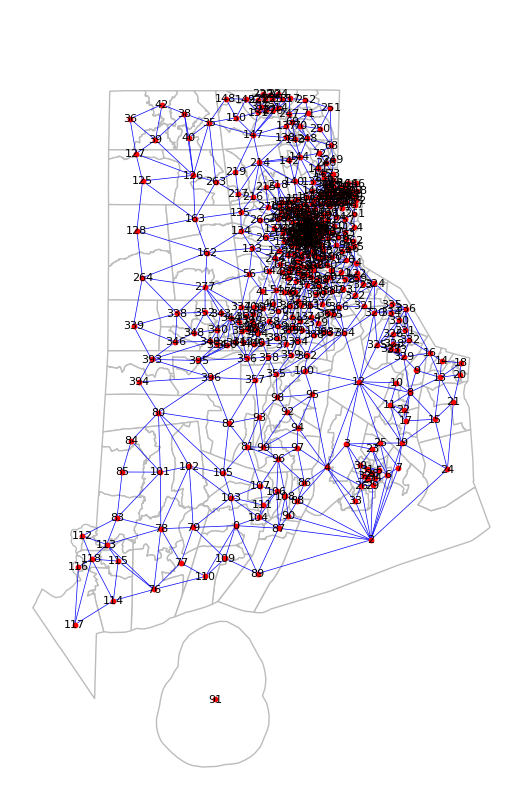

In [4]:
# CITE: https://networkx.org/documentation/stable/tutorial.html

from gerrychain import Graph

RI_df = gpd.read_file("./FinalShapeFiles/RI.shp")

fig, ax = plt.subplots(figsize=(10, 10))

RI_df.plot(ax=ax, color="white", edgecolor="#bcbcbc")

# get the centriod of each place
pos = {node: (RI_df.geometry[node].centroid.x, RI_df.geometry[node].centroid.y) for node in RI_graph.nodes}


nx.draw(RI_graph, 
        pos, 
        ax=ax, 
        node_size=10, 
        node_color="red", 
        edge_color="blue", 
        labels={node: node for node in RI_graph.nodes},
        font_size=8,         
        width=0.5
)

plt.title("Dual Graph of Rhode Island")
plt.show()

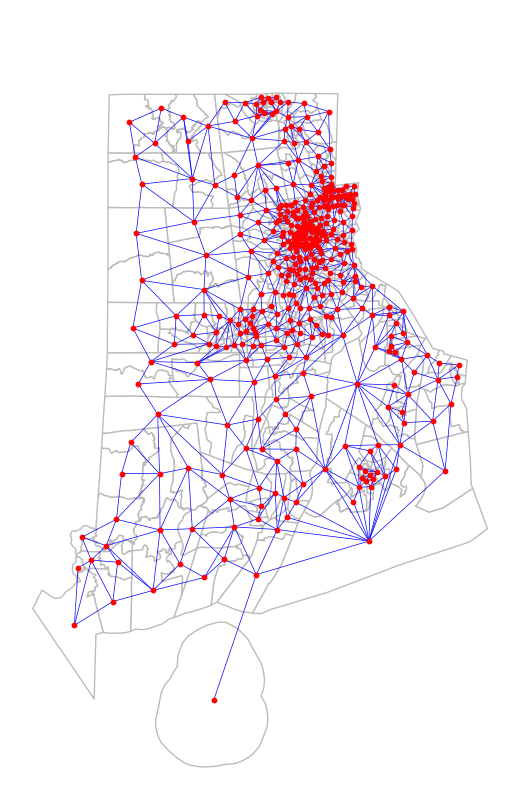

In [5]:
# As there's population, Look for rules for districting
# if there's population, add small number of edges.

# Connect node 89 and 110 with node 91
RI_graph.add_edge(89, 91)
           
# draw the graph again to verify
fig, ax = plt.subplots(figsize=(10, 10))

RI_df.plot(ax=ax, color="white", edgecolor="#bcbcbc")

# get the centriod of each place
pos = {node: (RI_df.geometry[node].centroid.x, RI_df.geometry[node].centroid.y) for node in RI_graph.nodes}

nx.draw(RI_graph, 
        pos, 
        ax=ax, 
        node_size=10, 
        node_color="red", 
        edge_color="blue", 
        width=0.5
)

plt.title("Modified Dual Graph of Rhode Island")
plt.show()

In [6]:

is_contig = nx.is_connected(RI_graph)
print(f"Dual graph is connected or not: {is_contig}")

Dual graph is connected or not: True


### Creating at least 2 Markov Chain ensembles using ReCom 
1. Use 2020 Presidential Election (G20PREDBID (Democrat), G20PRERTRU(Republican))
2. Use 2020 U.S. Senate Election (G20USSDREE (Democrat), G20USSRWAT(Republican))

In [7]:
ri_data = gpd.read_file("./FinalShapeFiles/RI.shp")
district_summary = ri_data.groupby("SEND")["TOTPOP"].sum()

total_population = district_summary.sum()
number_of_districts = len(district_summary)

ideal_pop = total_population / number_of_districts

pop_tolerance = 0.1
rw_proposal = partial(recom, ## how you choose a next districting plan
                      pop_col = "TOTPOP", ## What data describes population
                      pop_target = ideal_pop, ## What the target/ideal population is for each district 
                                              ## (we calculated ideal pop above)
                      epsilon = pop_tolerance,  ## how far from ideal population you can deviate
                                              ## (we set pop_tolerance above)
                      node_repeats = 2 ## number of times to repeat bipartition.  Can increase if you get a BipartitionWarning
                      )

In [8]:
# 1. 2020 Presidential Election
pres_election = Election(
    "Pres20",
    {"Dem": "PRES20D", "Rep": "PRES20R"}
)

# 2. 2020 U.S. Senate Election
senate_election = Election(
    "Sen20",
    {"Dem": "SEN20D", "Rep": "SEN20R"}
)

my_updaters = {
    "population": Tally("TOTPOP", alias="population"), 
    "cut_edges": cut_edges,
    "VAP": Tally("VAP", alias="VAP"),
    "HVAP": Tally("HVAP", alias="HVAP"),
    # "BVAP": Tally("BVAP", alias="BVAP"),
    "Pres20": pres_election,
    "Sen20": senate_election,

    # Get the efficiency gap
    "eff_gap_pres": lambda p: efficiency_gap(p["Pres20"]),
    "eff_gap_sen": lambda p: efficiency_gap(p["Sen20"])
}

initial_partition = Partition(
    RI_graph,              
    assignment="SEND",      
    updaters=my_updaters
)

TODO: Evidence of convergence (that you have run the chain long enough)

In [9]:
pres_dem_seats = []
sen_dem_seats = []
cutedge_ensemble = []
pres_eg_scores = []
sen_eg_scores = []
latino_districts_ensemble = []

population_constraint = constraints.within_percent_of_ideal_population(
    initial_partition,
    pop_tolerance
)

our_random_walk = MarkovChain(
    proposal = rw_proposal, 
    constraints = [population_constraint], # Could add additional constraints here
    accept = always_accept, # Accept every proposed plan that meets the population constraints
    initial_state = initial_partition, 
    total_steps = 40000)  


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for part in our_random_walk:
        cutedge_ensemble.append(len(part["cut_edges"]))

        pres_dem_seats.append(part["Pres20"].wins("Dem"))
        sen_dem_seats.append(part["Sen20"].wins("Dem"))

        pres_eg_scores.append(part["eff_gap_pres"])
        sen_eg_scores.append(part["eff_gap_sen"])

        num_lat_majority = 0
        for dist in part["HVAP"]:
            if part["VAP"][dist] > 0:
                hvap_share = part["HVAP"][dist] / part["VAP"][dist]
                if hvap_share >= 0.5:
                    num_lat_majority += 1

        latino_districts_ensemble.append(num_lat_majority)

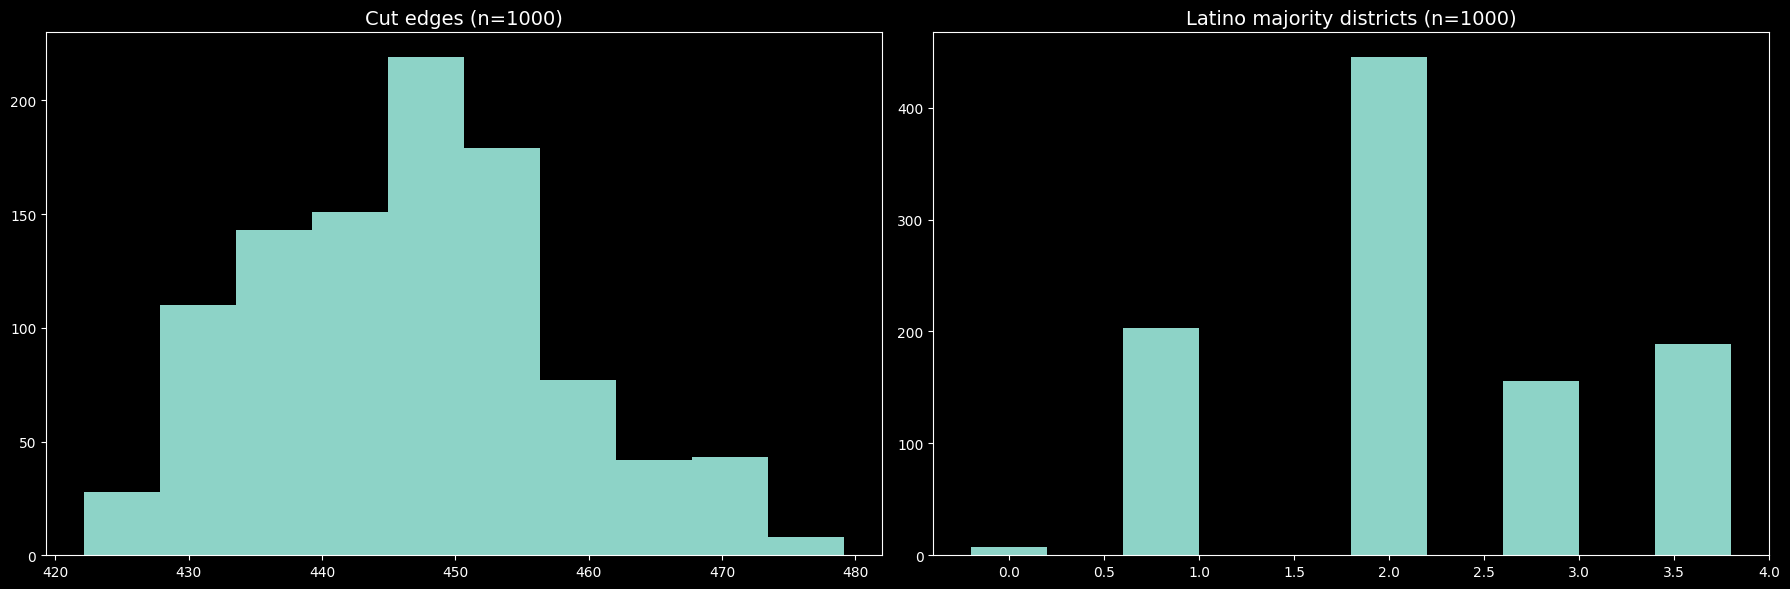

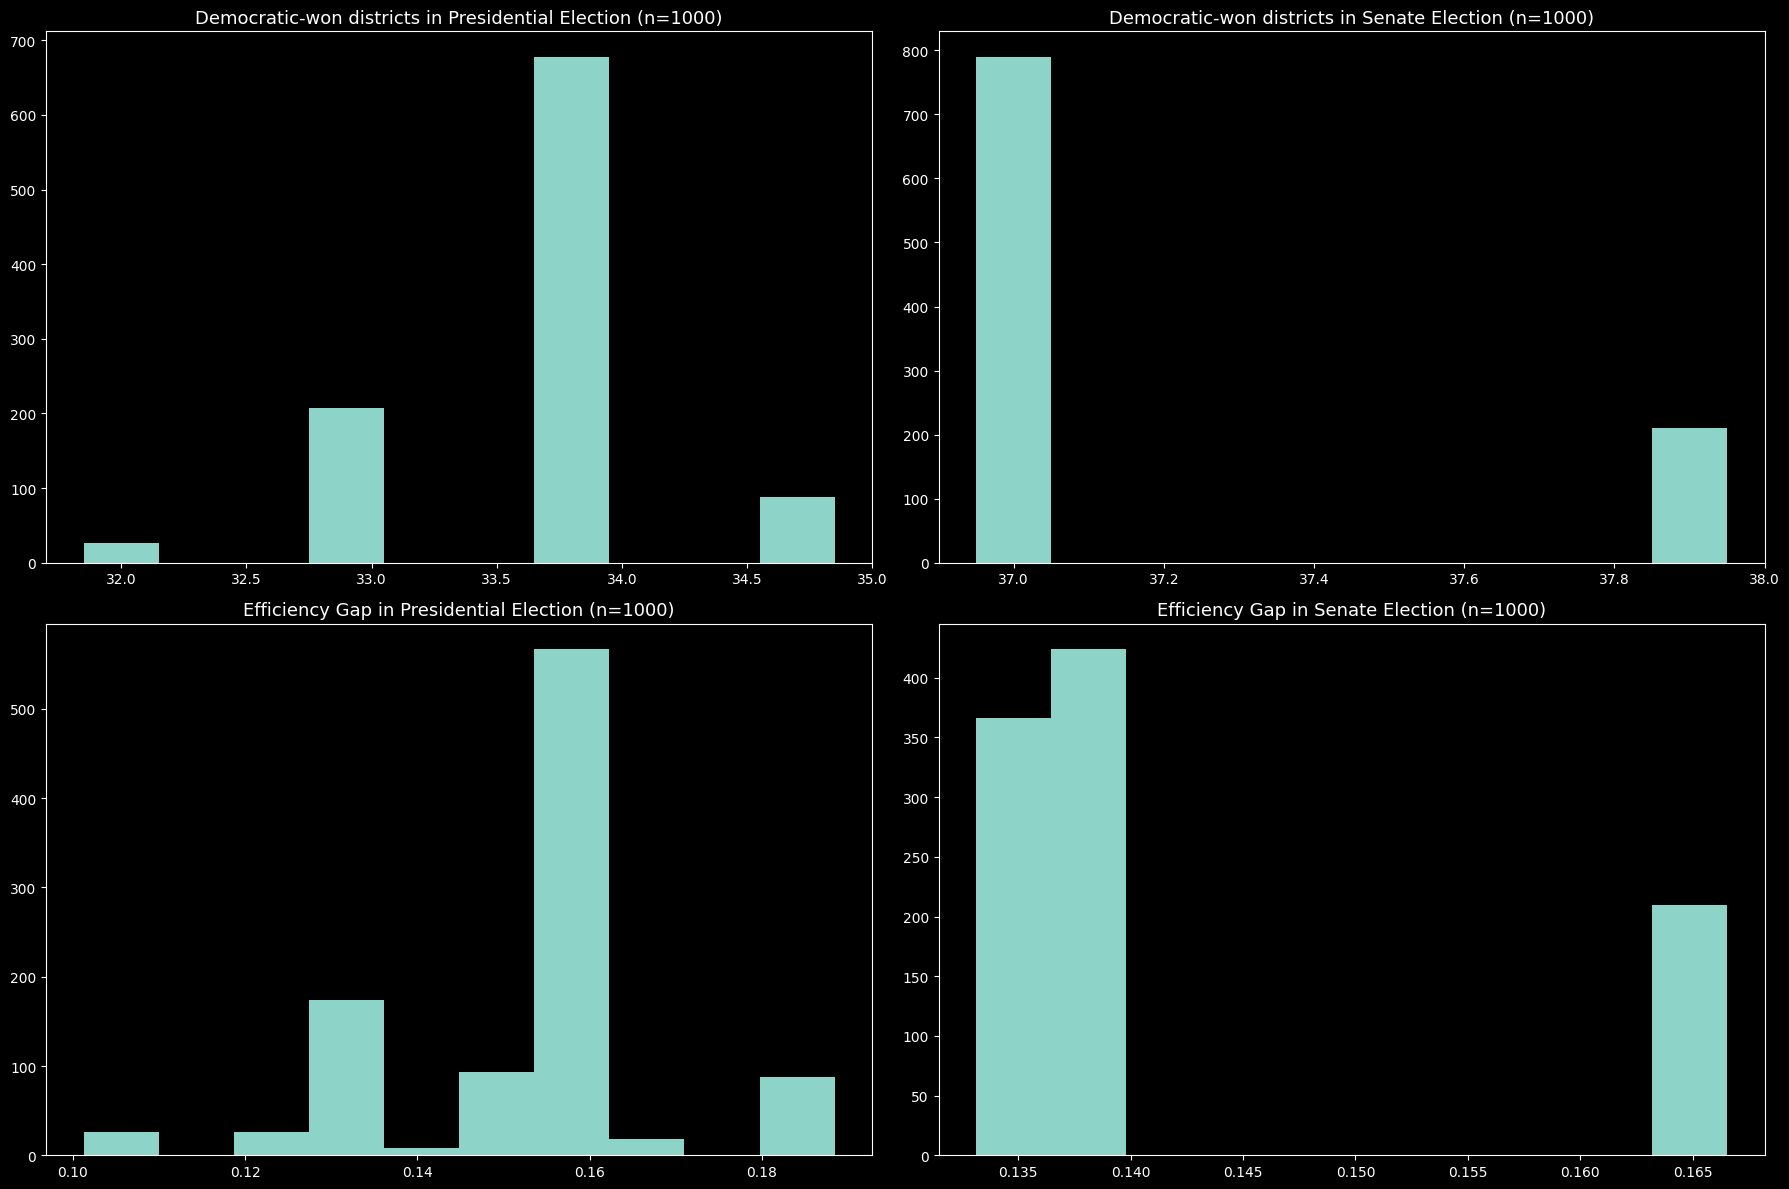

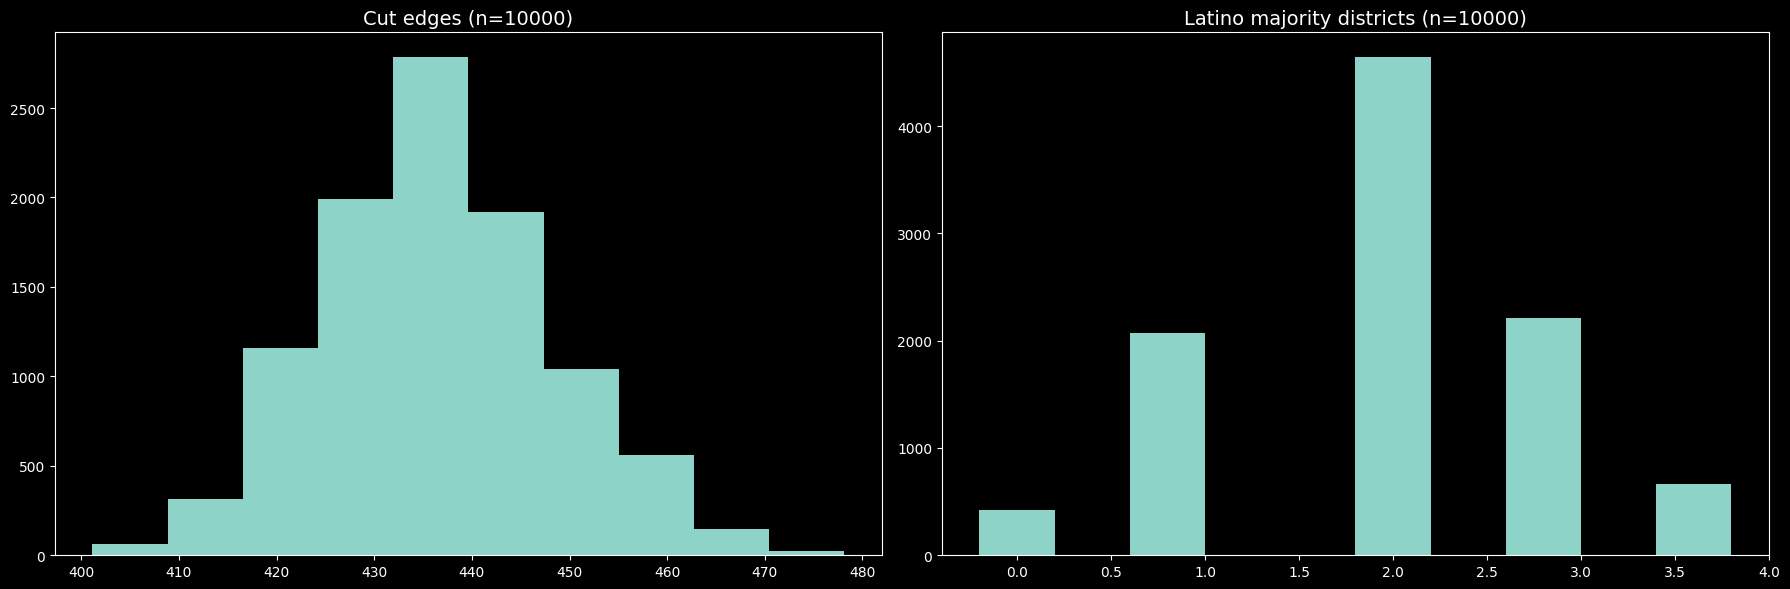

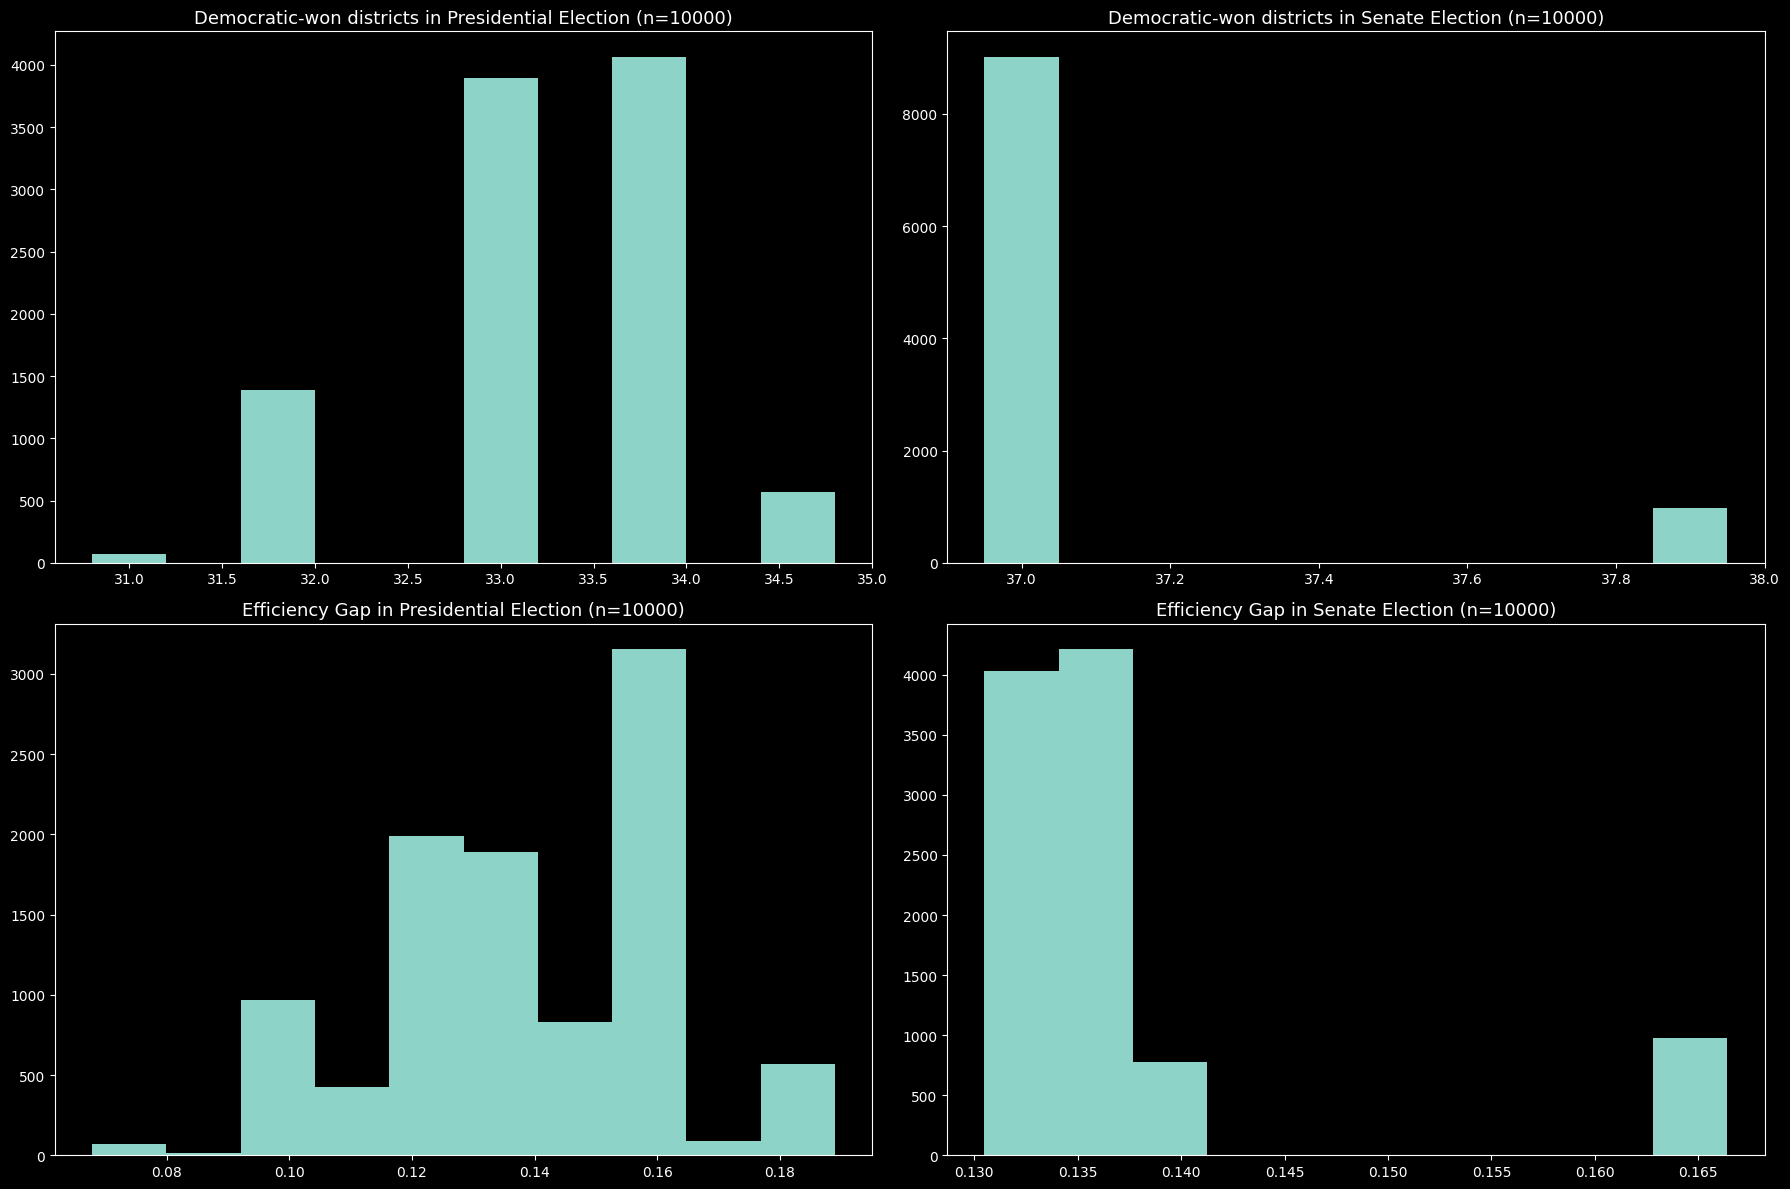

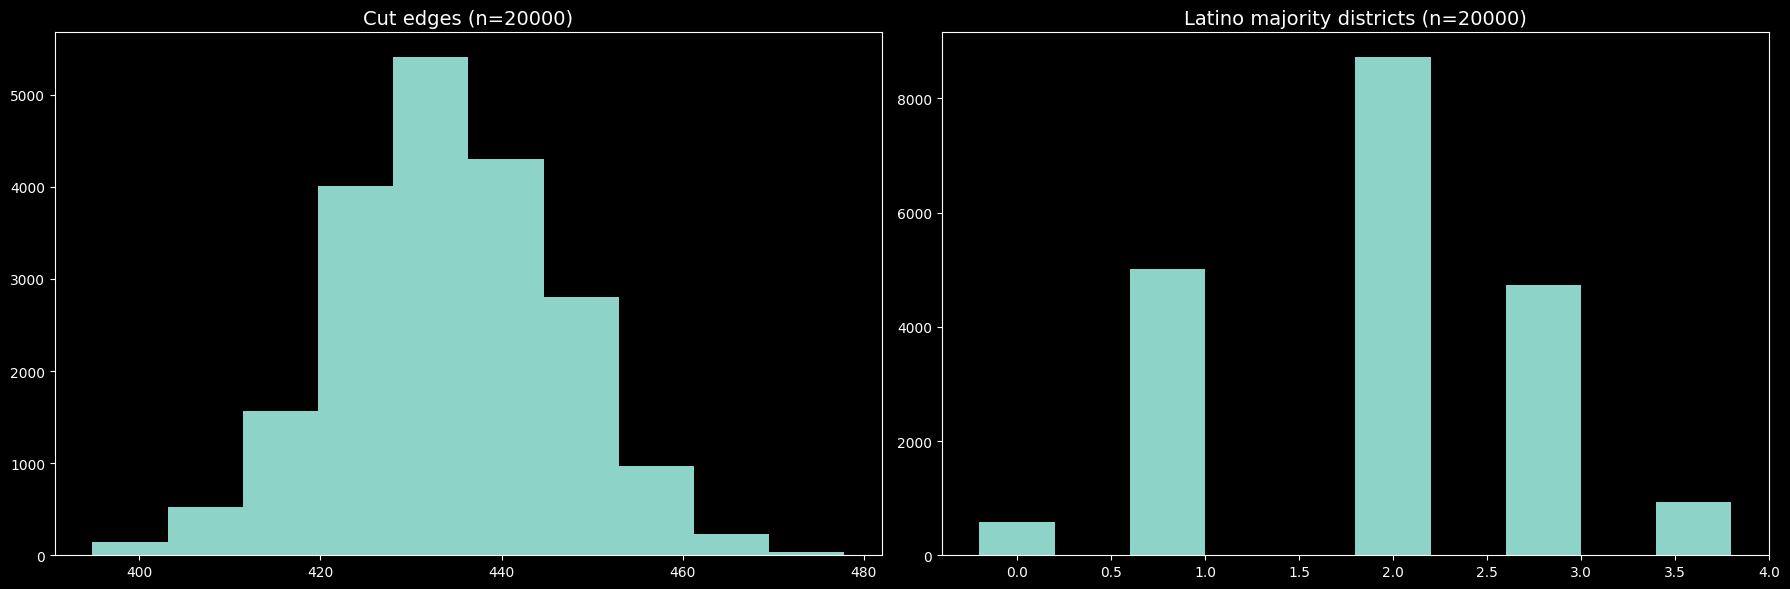

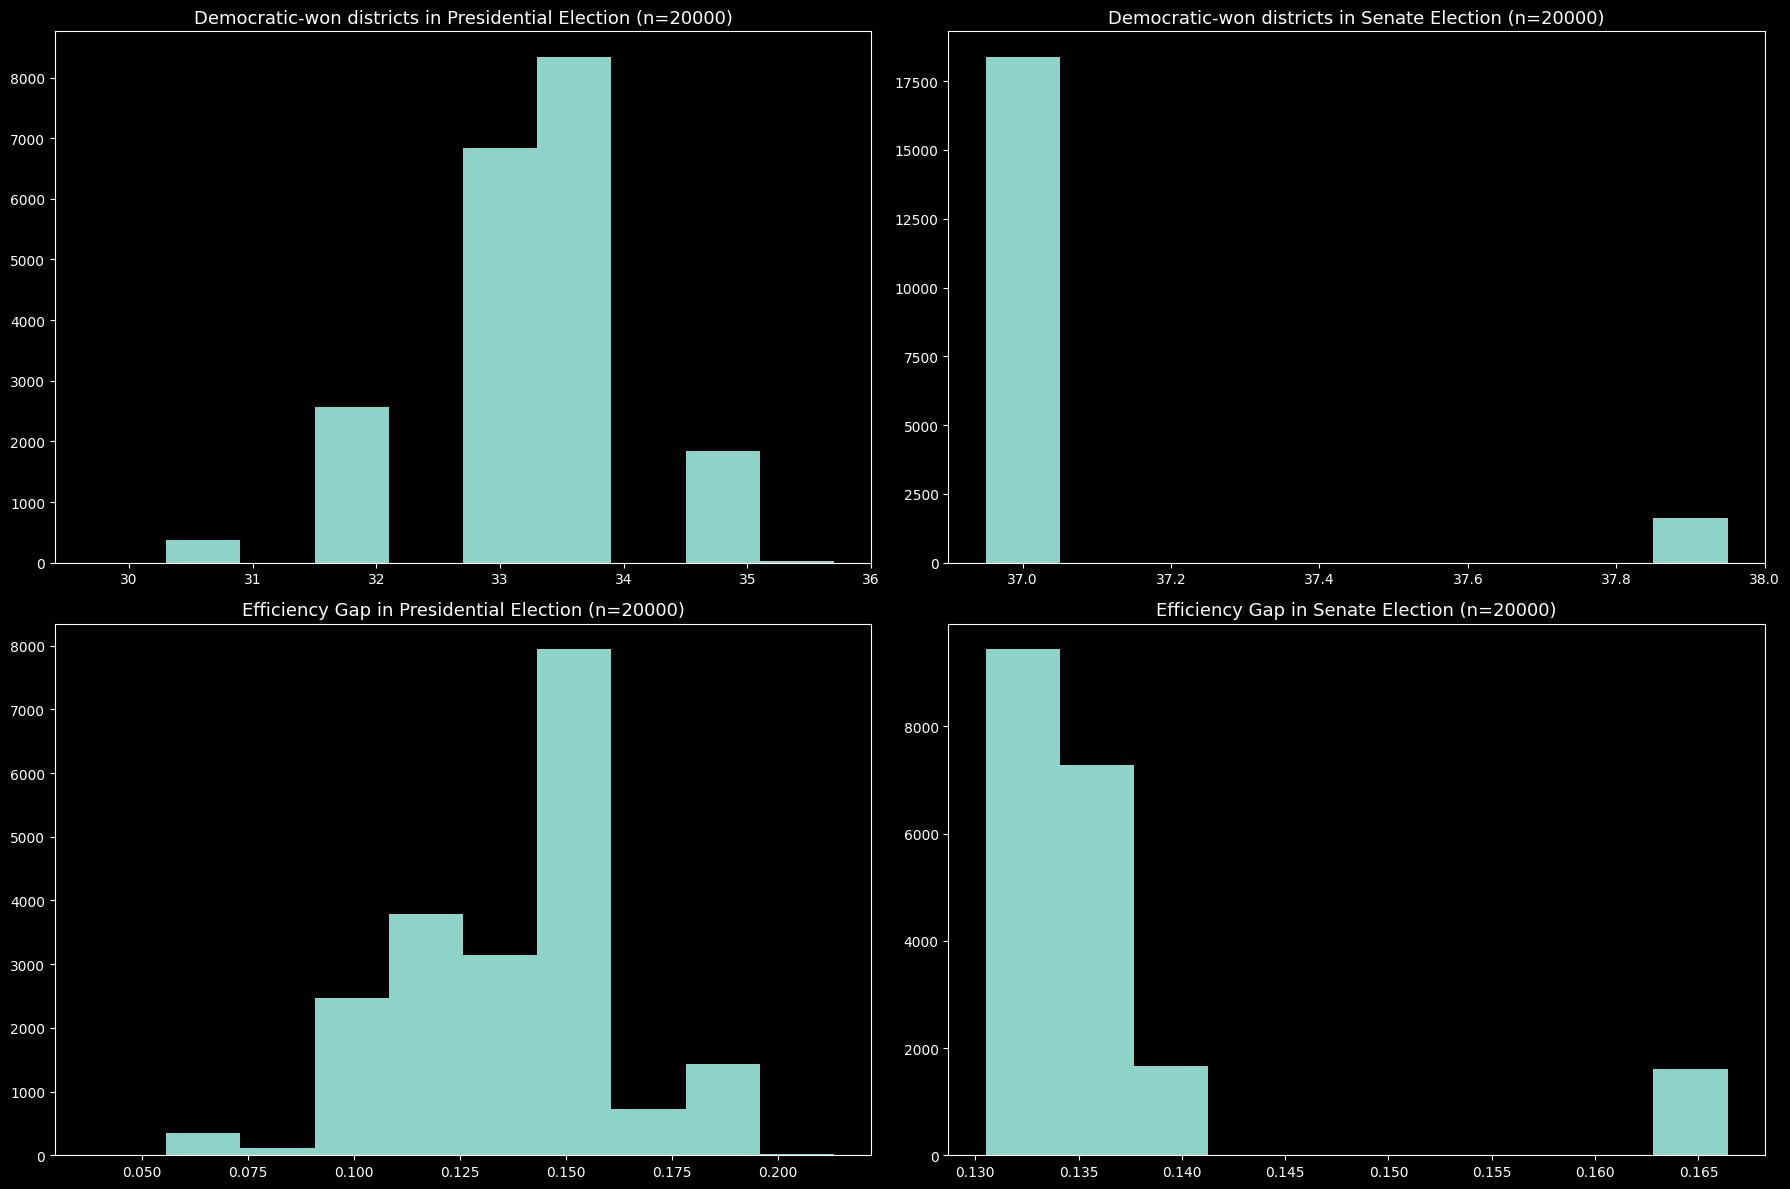

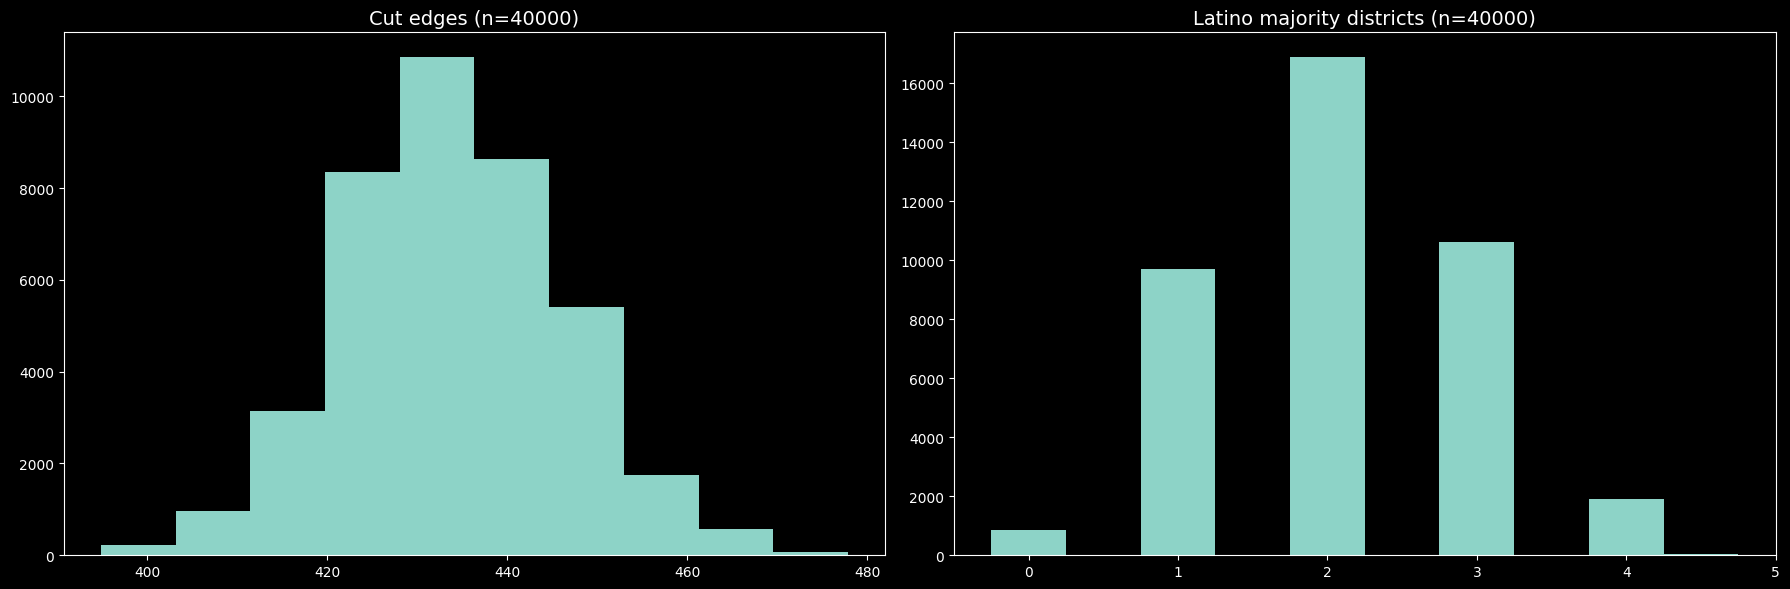

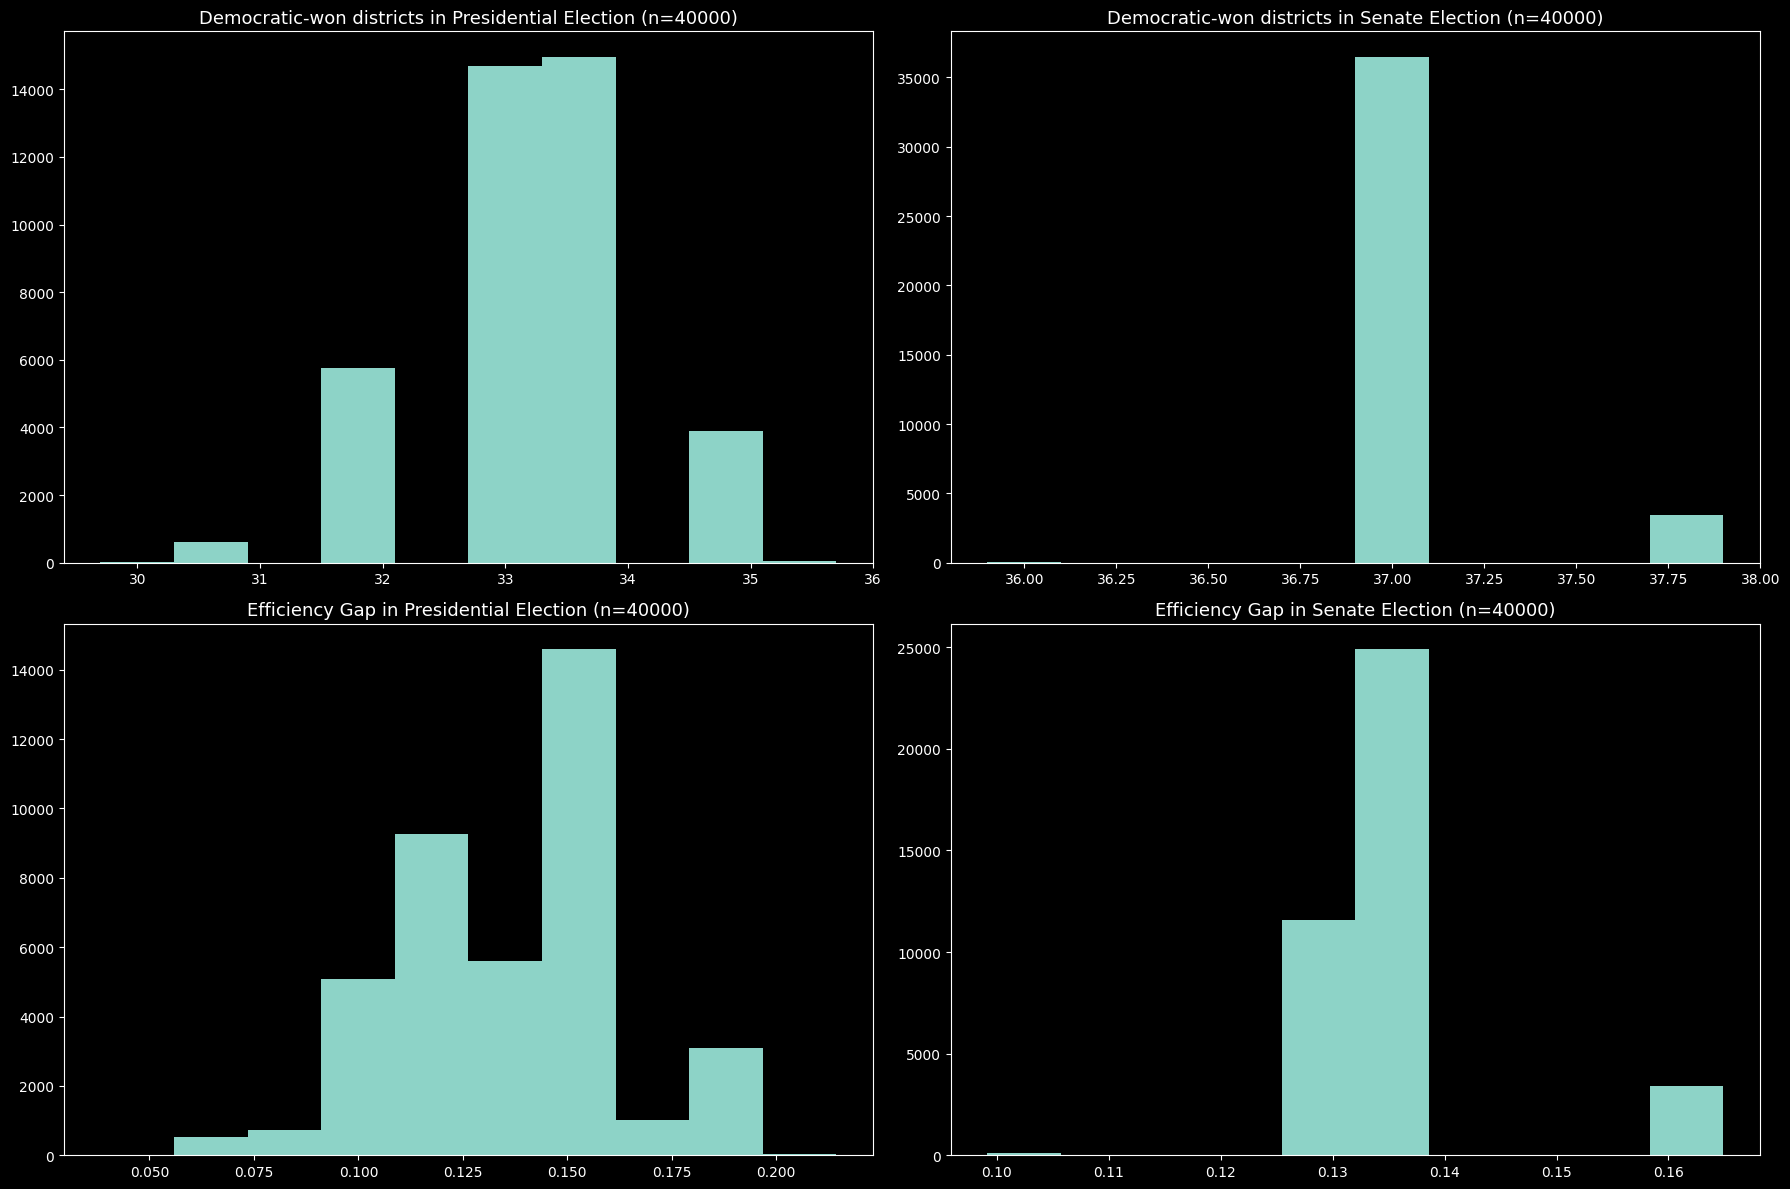

In [10]:
for size in [1000, 10000, 20000, 40000]:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    axes[0].hist(cutedge_ensemble[:size], align='left')
    axes[0].set_title(f"Cut edges (n={size})", fontsize=14)

    axes[1].hist(latino_districts_ensemble[:size], align='left')
    axes[1].set_title(f"Latino majority districts (n={size})", fontsize=14)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    axes[0][0].hist(pres_dem_seats[:size], align='left')
    axes[0][0].set_title(f"Democratic-won districts in Presidential Election (n={size})", fontsize=13)

    axes[0][1].hist(sen_dem_seats[:size], align='left')
    axes[0][1].set_title(f"Democratic-won districts in Senate Election (n={size})", fontsize=13)

    axes[1][0].hist(pres_eg_scores[:size], align='left')
    axes[1][0].set_title(f"Efficiency Gap in Presidential Election (n={size})", fontsize=13)

    axes[1][1].hist(sen_eg_scores[:size], align='left')
    axes[1][1].set_title(f"Efficiency Gap in Senate Election (n={size})", fontsize=13)

    plt.tight_layout()
    plt.show()

Marginal box plots (sometimes called the “signature of gerrymandering”)

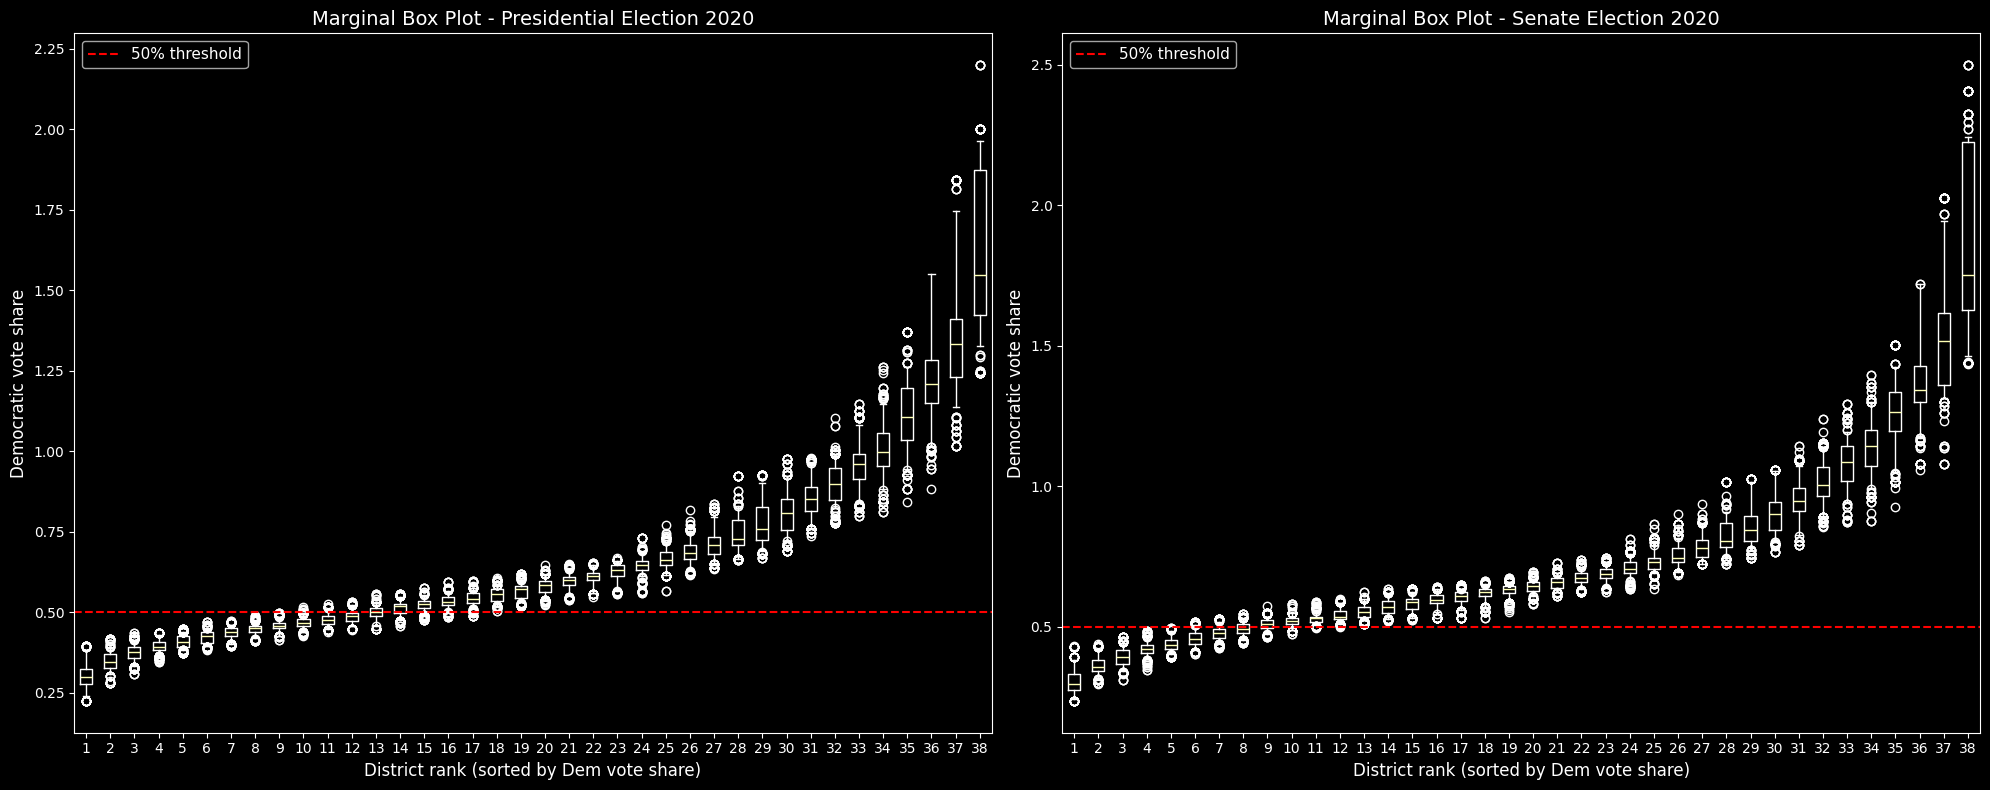

In [11]:
# Marginal box plots - "signature of gerrymandering"
# Each box shows the distribution of Dem vote share for one district rank
# across all steps in the ensemble.
pres_district_shares = []
sen_district_shares  = []

boxplot_walk = MarkovChain(
    proposal=rw_proposal,
    constraints=[population_constraint],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=500
)

for part in boxplot_walk:
    pres_results = part["Pres20"]
    sen_results  = part["Sen20"]

    # Compute Dem vote share per district manually (avoids percents() API differences)
    pres_shares = sorted([
        pres_results.counts("Dem")[d] / pres_results.totals[d]
        for d in part.parts
        if pres_results.totals[d] > 0
    ])
    sen_shares = sorted([
        sen_results.counts("Dem")[d] / sen_results.totals[d]
        for d in part.parts
        if sen_results.totals[d] > 0
    ])
    pres_district_shares.append(pres_shares)
    sen_district_shares.append(sen_shares)

# Transpose: each element = all values for one district rank across chain steps
pres_by_rank = list(zip(*pres_district_shares))
sen_by_rank  = list(zip(*sen_district_shares))

num_districts = len(pres_by_rank)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Presidential
axes[0].boxplot(pres_by_rank, positions=range(1, num_districts + 1), whis=[5, 95])
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
axes[0].set_xlabel("District rank (sorted by Dem vote share)", fontsize=12)
axes[0].set_ylabel("Democratic vote share", fontsize=12)
axes[0].set_title("Marginal Box Plot - Presidential Election 2020", fontsize=14)
axes[0].legend(fontsize=11)

# Senate
axes[1].boxplot(sen_by_rank, positions=range(1, num_districts + 1), whis=[5, 95])
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
axes[1].set_xlabel("District rank (sorted by Dem vote share)", fontsize=12)
axes[1].set_ylabel("Democratic vote share", fontsize=12)
axes[1].set_title("Marginal Box Plot - Senate Election 2020", fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()